# 09 Evaluation Comparison

Notebook ini membandingkan tiga hasil eksperimen GraphEdgeClassifier untuk NFT Wash Trading Detection:

1. Graph + Class Weight
2. Graph Plain Training
3. Graph + Focal Loss

Tujuan notebook ini adalah mengurutkan model terbaik berdasarkan hasil final test evaluation.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("../outputs/metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Final Test Results dari Tiga Eksperimen

Nilai di bawah diambil dari final test evaluation pada notebook training masing-masing.

In [16]:
results = [
    {
        "model_name": "Graph + Class Weight",
        "notebook": "06_train_graph_class_weight.ipynb",
        "threshold_strategy": "fp_budget_then_recall",
        "threshold": 0.9010158498287203,
        "accuracy": 0.9510259660985115,
        "precision": 0.0038329911019849418,
        "recall": 0.5384615384615384,
        "f1": 0.007611798287345386,
        "roc_auc": 0.7350329134988962,
        "pr_auc": 0.053153929825627895,
        "tn": 141750.0,
        "fp": 7277.0,
        "fn": 24.0,
        "tp": 28.0
    },
    {
        "model_name": "Graph Plain",
        "notebook": "07_train_graph_plain.ipynb",
        "threshold_strategy": "recall_target_0.8_min_fp_on_validation",
        "threshold": 9.955421634003868e-06,
        "accuracy": 0.3336698416957338,
        "precision": 0.00028180212458673215,
        "recall": 0.875,
        "f1": 0.0005634227934703322,
        "roc_auc": 0.6475769865244754,
        "pr_auc": 0.00037697994446690925,
        "tn": 99431,
        "fp": 198665,
        "fn": 8,
        "tp": 56
    },
    {
        "model_name": "Graph + Focal Loss",
        "notebook": "08_train_graph_focal_loss.ipynb",
        "threshold_strategy": "fp_budget_then_recall",
        "threshold": 0.7187257040739048,
        "accuracy": 0.9610206668947336,
        "precision": 0.004815133276010318,
        "recall": 0.5384615384615384,
        "f1": 0.00954491222089654,
        "roc_auc": 0.7402513793318815,
        "pr_auc": 0.04284346666916614,
        "tn": 143240.0,
        "fp": 5787.0,
        "fn": 24.0,
        "tp": 28.0
    },
]

comparison_df = pd.DataFrame(results)
comparison_df

,model_name,notebook,threshold_strategy,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Graph + Class Weight,06_train_graph_class_weight.ipynb,fp_budget_then_recall,0.901016,0.951026,0.003833,0.538462,0.007612,0.735033,0.053154,141750.0,7277.0,24.0,28.0
1,Graph Plain,07_train_graph_plain.ipynb,recall_target_0.8_min_fp_on_validation,0.000010,0.333670,0.000282,0.875000,0.000563,0.647577,0.000377,99431.0,198665.0,8.0,56.0
2,Graph + Focal Loss,08_train_graph_focal_loss.ipynb,fp_budget_then_recall,0.718726,0.961021,0.004815,0.538462,0.009545,0.740251,0.042843,143240.0,5787.0,24.0,28.0


## 2. Ranking Model

Karena dataset sangat imbalanced, ranking utama menggunakan **PR-AUC** dan **F1-score**. PR-AUC lebih relevan daripada accuracy untuk kasus fraud detection karena jumlah kelas fraud sangat kecil. Recall tetap dilihat, tetapi recall tinggi dengan false positive yang sangat besar tidak otomatis berarti model lebih baik.

In [17]:
ranking_df = comparison_df.copy()

# Ranking metric: semakin kecil rank semakin baik.
ranking_df["rank_pr_auc"] = ranking_df["pr_auc"].rank(ascending=False, method="min")
ranking_df["rank_f1"] = ranking_df["f1"].rank(ascending=False, method="min")
ranking_df["rank_roc_auc"] = ranking_df["roc_auc"].rank(ascending=False, method="min")
ranking_df["rank_precision"] = ranking_df["precision"].rank(ascending=False, method="min")
ranking_df["rank_fp"] = ranking_df["fp"].rank(ascending=True, method="min")

# Composite score dipakai hanya untuk mengurutkan model secara ringkas.
# Bobot terbesar diberikan ke PR-AUC dan F1 karena kasusnya fraud detection dengan class imbalance ekstrem.
ranking_df["composite_rank_score"] = (
    0.35 * ranking_df["rank_pr_auc"] +
    0.25 * ranking_df["rank_f1"] +
    0.15 * ranking_df["rank_roc_auc"] +
    0.15 * ranking_df["rank_precision"] +
    0.10 * ranking_df["rank_fp"]
)

ranking_df = ranking_df.sort_values(
    by=["composite_rank_score", "pr_auc", "f1", "fp"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

ranking_df.insert(0, "final_rank", np.arange(1, len(ranking_df) + 1))
ranking_df[[
    "final_rank", "model_name", "pr_auc", "f1", "roc_auc", "precision", "recall",
    "accuracy", "tp", "fp", "fn", "tn", "threshold", "composite_rank_score"
]]

,final_rank,model_name,pr_auc,f1,roc_auc,precision,recall,accuracy,tp,fp,fn,tn,threshold,composite_rank_score
0,1,Graph + Focal Loss,0.042843,0.009545,0.740251,0.004815,0.538462,0.961021,28.0,5787.0,24.0,143240.0,0.718726,1.35
1,2,Graph + Class Weight,0.053154,0.007612,0.735033,0.003833,0.538462,0.951026,28.0,7277.0,24.0,141750.0,0.901016,1.65
2,3,Graph Plain,0.000377,0.000563,0.647577,0.000282,0.875000,0.333670,56.0,198665.0,8.0,99431.0,0.000010,3.00


## 3. Best Model Summary

In [18]:
best_model = ranking_df.iloc[0]

print("BEST MODEL:", best_model["model_name"])
print("Alasan utama:")
print(f"- PR-AUC tertinggi: {best_model['pr_auc']:.6f}")
print(f"- F1-score tertinggi: {best_model['f1']:.6f}")
print(f"- ROC-AUC tertinggi: {best_model['roc_auc']:.6f}")
print(f"- False positive paling rendah di antara tiga model: {int(best_model['fp'])}")
print(f"- Recall tetap sama dengan Class Weight: {best_model['recall']:.6f}")

BEST MODEL: Graph + Focal Loss
Alasan utama:
- PR-AUC tertinggi: 0.042843
- F1-score tertinggi: 0.009545
- ROC-AUC tertinggi: 0.740251
- False positive paling rendah di antara tiga model: 5787
- Recall tetap sama dengan Class Weight: 0.538462


## 4. Visual Comparison

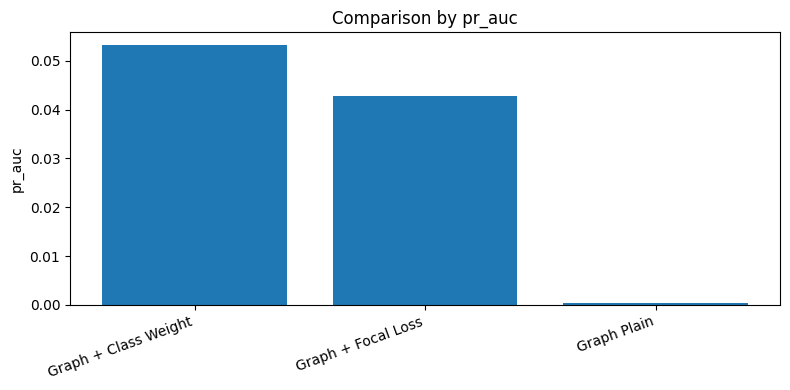

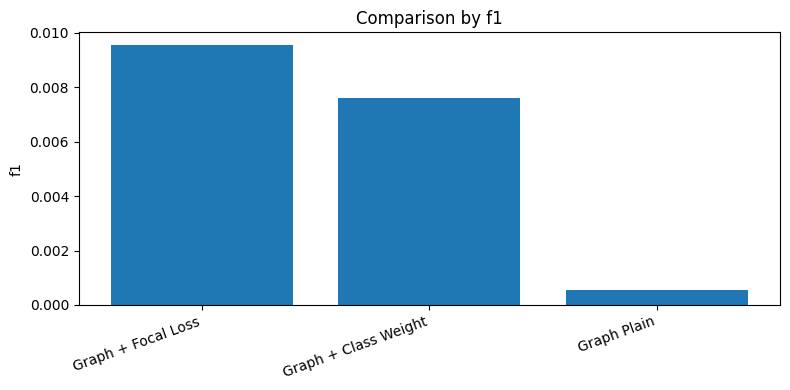

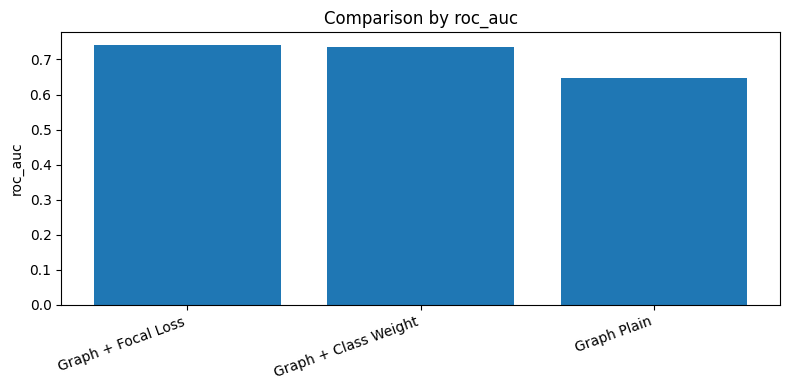

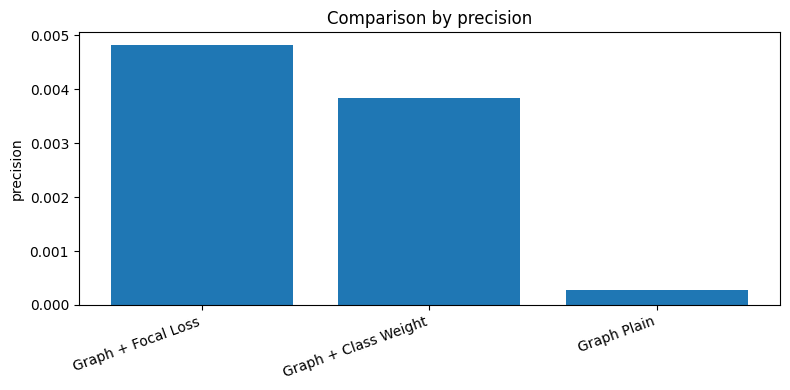

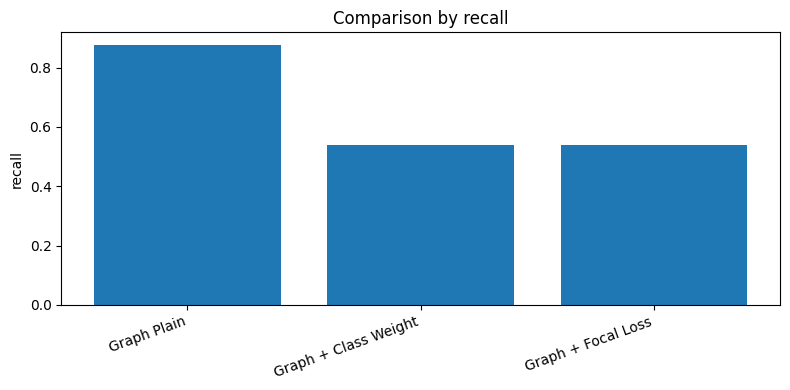

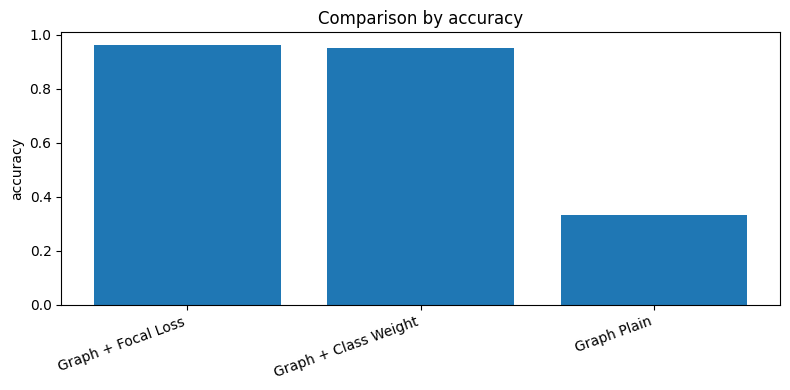

In [19]:
metric_cols = ["pr_auc", "f1", "roc_auc", "precision", "recall", "accuracy"]

for metric in metric_cols:
    plot_df = comparison_df.sort_values(metric, ascending=False)
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["model_name"], plot_df[metric])
    plt.title(f"Comparison by {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

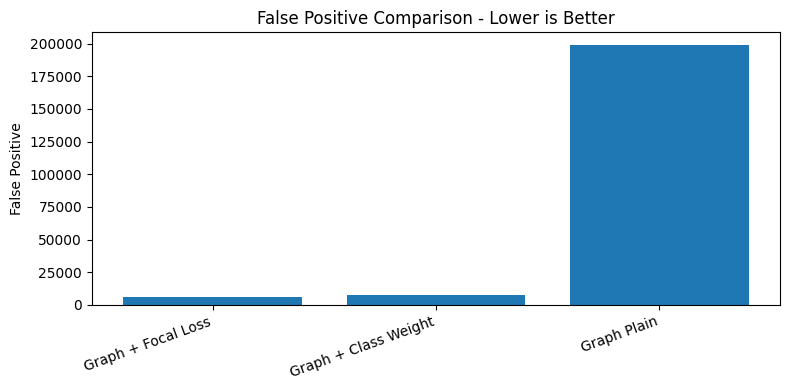

In [20]:
plot_df = comparison_df.sort_values("fp", ascending=True)
plt.figure(figsize=(8, 4))
plt.bar(plot_df["model_name"], plot_df["fp"])
plt.title("False Positive Comparison - Lower is Better")
plt.ylabel("False Positive")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Kesimpulan

Urutan model terbaik berdasarkan final test evaluation adalah:

1. **Graph + Focal Loss**
2. **Graph + Class Weight**
3. **Graph Plain**

Model **Graph + Focal Loss** menjadi model terbaik karena memiliki PR-AUC, F1-score, ROC-AUC, precision, dan accuracy tertinggi, sekaligus false positive paling rendah. Model Plain memiliki recall paling tinggi, tetapi false positive-nya juga paling besar sehingga kurang stabil untuk fraud detection pada data yang sangat imbalanced.

In [21]:
# Save comparison outputs
comparison_path = OUTPUT_DIR / "model_comparison_final_test.csv"
ranking_path = OUTPUT_DIR / "model_ranking_final_test.csv"

comparison_df.to_csv(comparison_path, index=False)
ranking_df.to_csv(ranking_path, index=False)

print("Saved:")
print("-", comparison_path)
print("-", ranking_path)

Saved:
- ..\outputs\metrics\model_comparison_final_test.csv
- ..\outputs\metrics\model_ranking_final_test.csv
